# Traffic Sign Recognition - 02: Transfer Learning

A frozen ImageNet-pretrained ResNet18 maps each image to a 512-d feature vector; a logistic-regression classifier is trained on those features (stratified 70/30 split). The CNN is never fine-tuned.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
from sklearn.model_selection import train_test_split
device = utils.get_device(); print('device:', device)
imgs, labels, classes = utils.load_sample()
print(len(imgs),'images,',len(classes),'classes')

device: mps


2580 images, 43 classes


## 1. Extract ResNet18 features

In [2]:
net = utils.build_extractor(device)
X = utils.extract_features(net, imgs, device)
y = np.array(labels)
print('feature matrix:', X.shape)

feature matrix: (2580, 512)


## 2. Train / test split + linear classifier

In [3]:
Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
clf = utils.train_classifier(Xtr, ytr)
acc, cm, preds = utils.evaluate(clf, Xte, yte, classes)
print('TEST ACCURACY: %.4f  (%d / %d)' % (acc, int(round(acc*len(yte))), len(yte)))

TEST ACCURACY: 0.9935  (769 / 774)


## 3. Confusion matrix

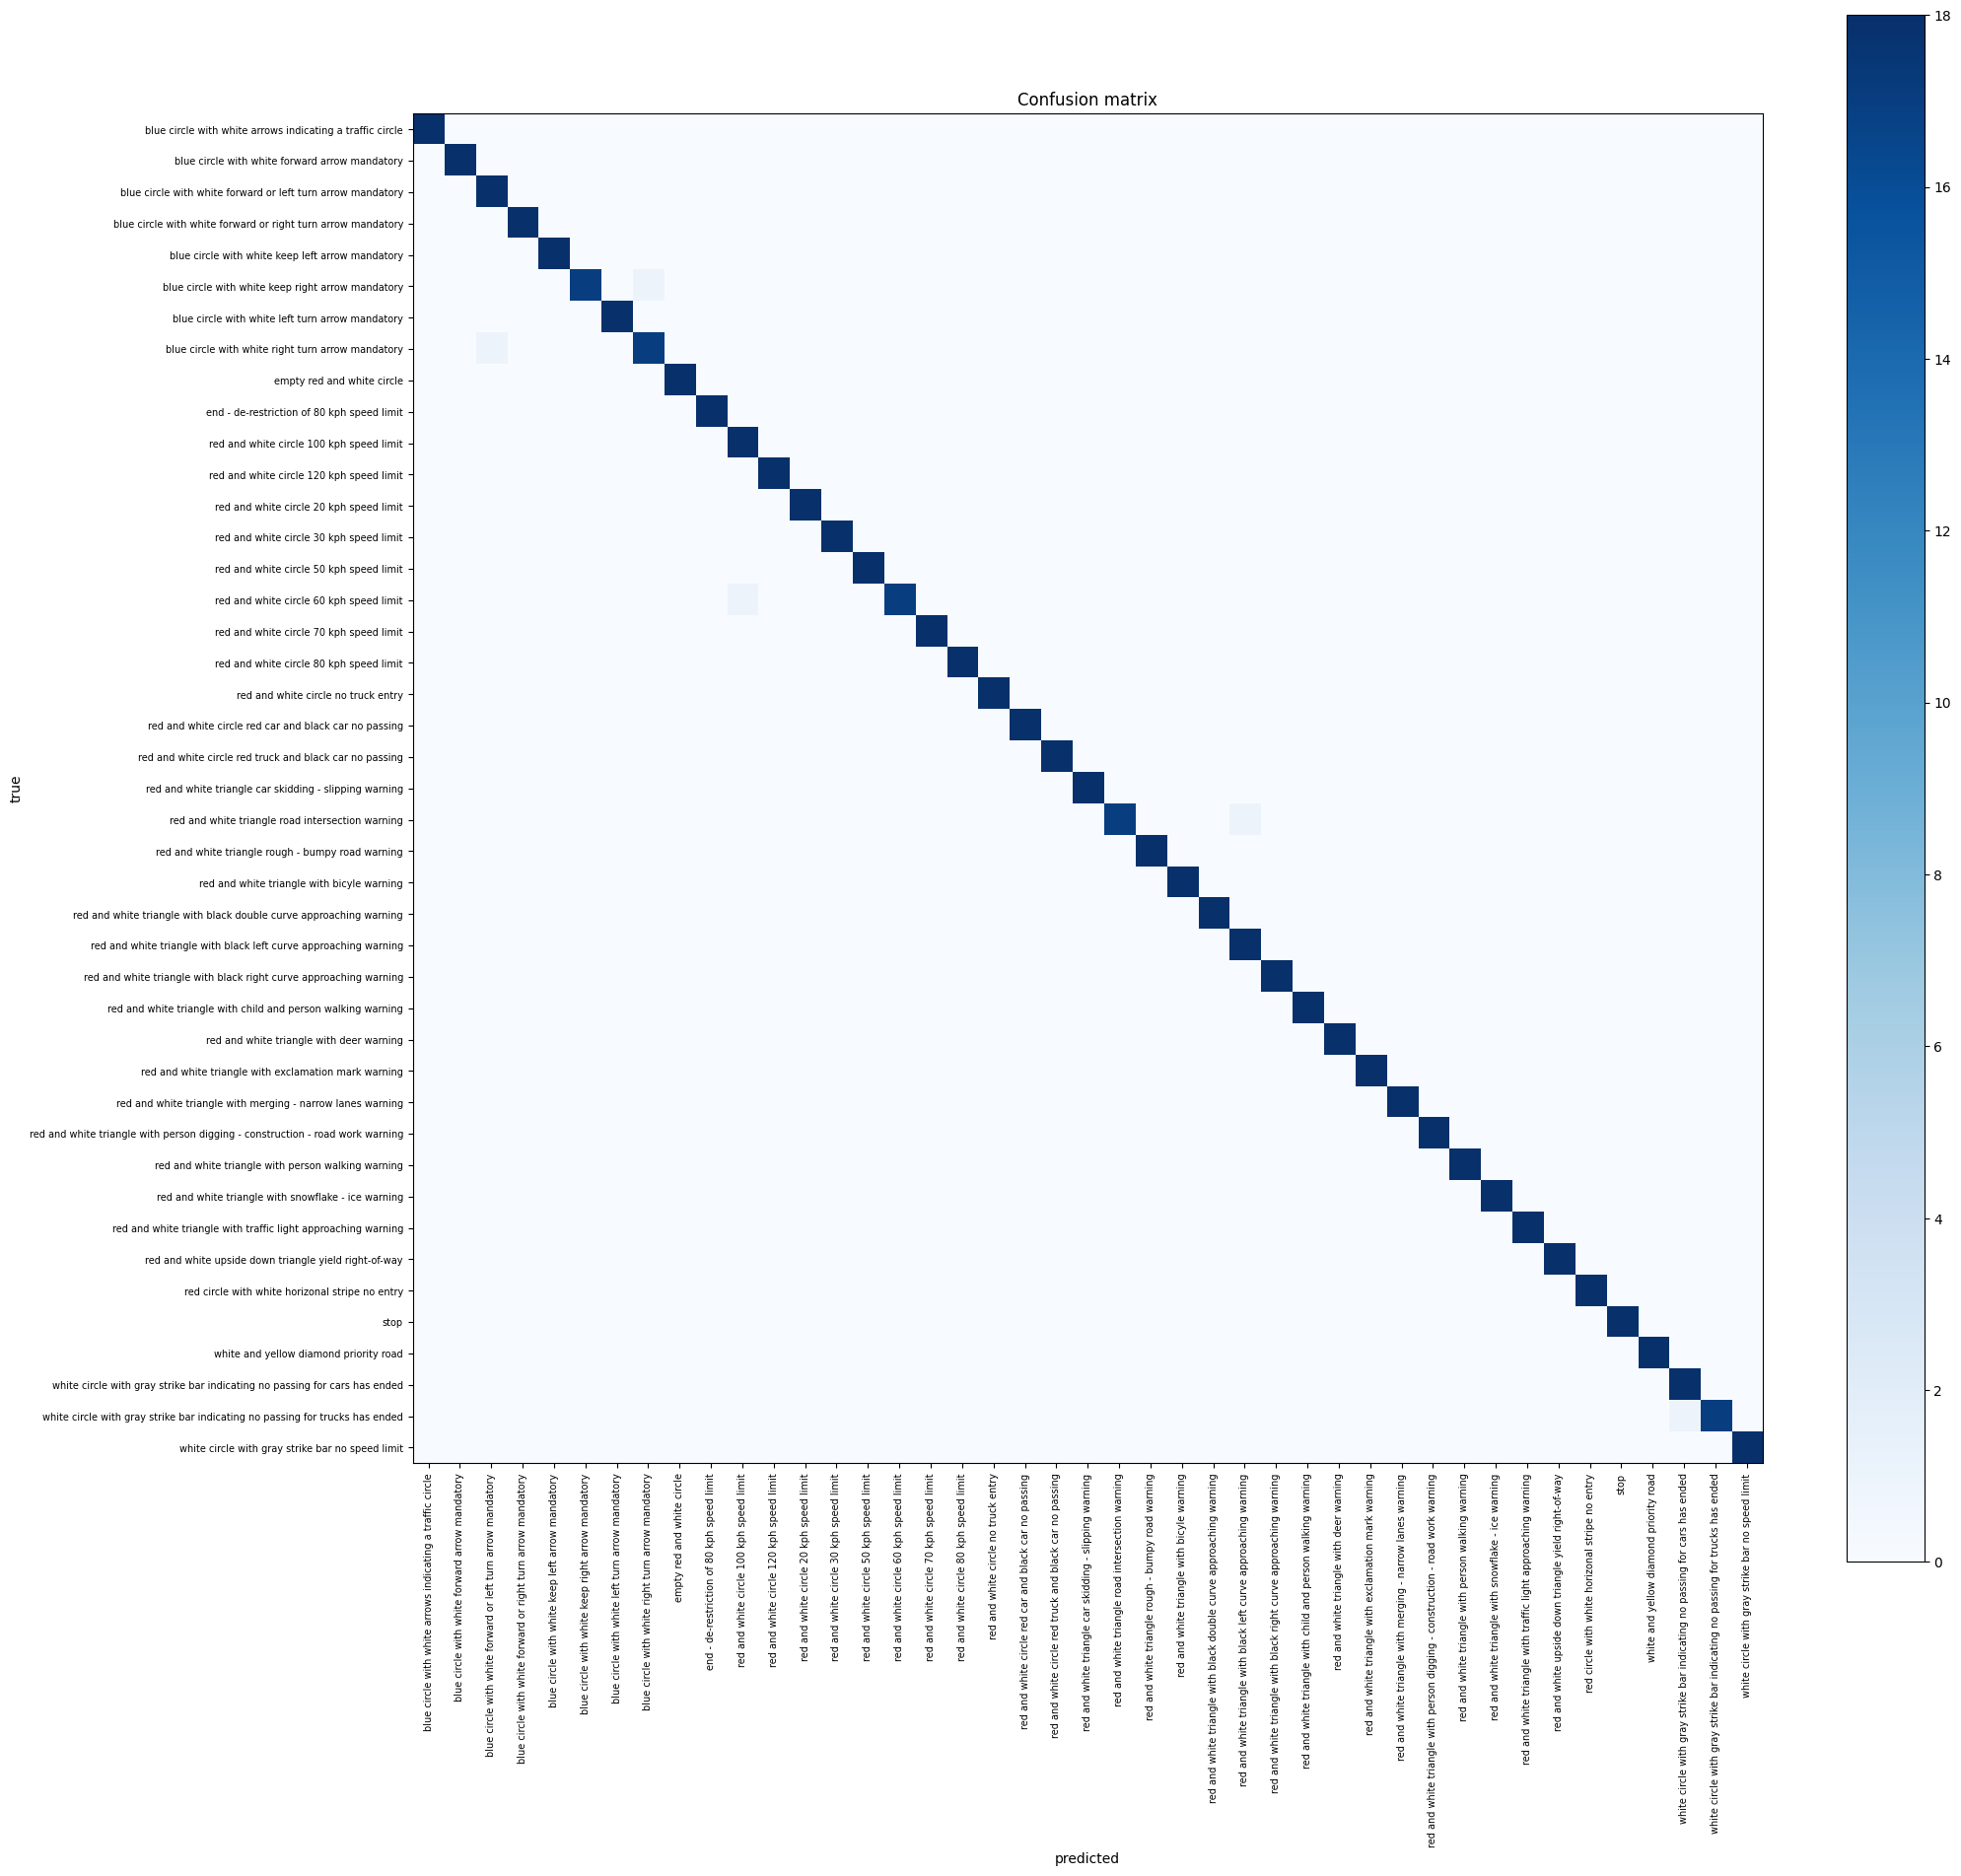

In [4]:
plt.figure(figsize=(max(5,len(classes)*0.5),max(4,len(classes)*0.45))); plt.imshow(cm, cmap='Blues'); plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=90, fontsize=7)
plt.yticks(range(len(classes)), classes, fontsize=7)
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Confusion matrix'); plt.tight_layout(); plt.show()

## 4. Per-class accuracy

In [5]:
order=[]
for i,cls in enumerate(classes):
    tot=cm[i].sum()
    if tot: order.append((cm[i,i]/tot, cls, cm[i,i], tot))
for r,cls,c,t in sorted(order):
    print('%-22s %.2f  (%d/%d)' % (cls, r, c, t))

blue circle with white keep right arrow mandatory 0.94  (17/18)
blue circle with white right turn arrow mandatory 0.94  (17/18)
red and white circle 60 kph speed limit 0.94  (17/18)
red and white triangle road intersection warning 0.94  (17/18)
white circle with gray strike bar indicating no passing for trucks has ended 0.94  (17/18)
blue circle with white arrows indicating a traffic circle 1.00  (18/18)
blue circle with white forward arrow mandatory 1.00  (18/18)
blue circle with white forward or left turn arrow mandatory 1.00  (18/18)
blue circle with white forward or right turn arrow mandatory 1.00  (18/18)
blue circle with white keep left arrow mandatory 1.00  (18/18)
blue circle with white left turn arrow mandatory 1.00  (18/18)
empty red and white circle 1.00  (18/18)
end - de-restriction of 80 kph speed limit 1.00  (18/18)
red and white circle 100 kph speed limit 1.00  (18/18)
red and white circle 120 kph speed limit 1.00  (18/18)
red and white circle 20 kph speed limit 1.00  (1

## 5. Sample predictions (red = wrong)

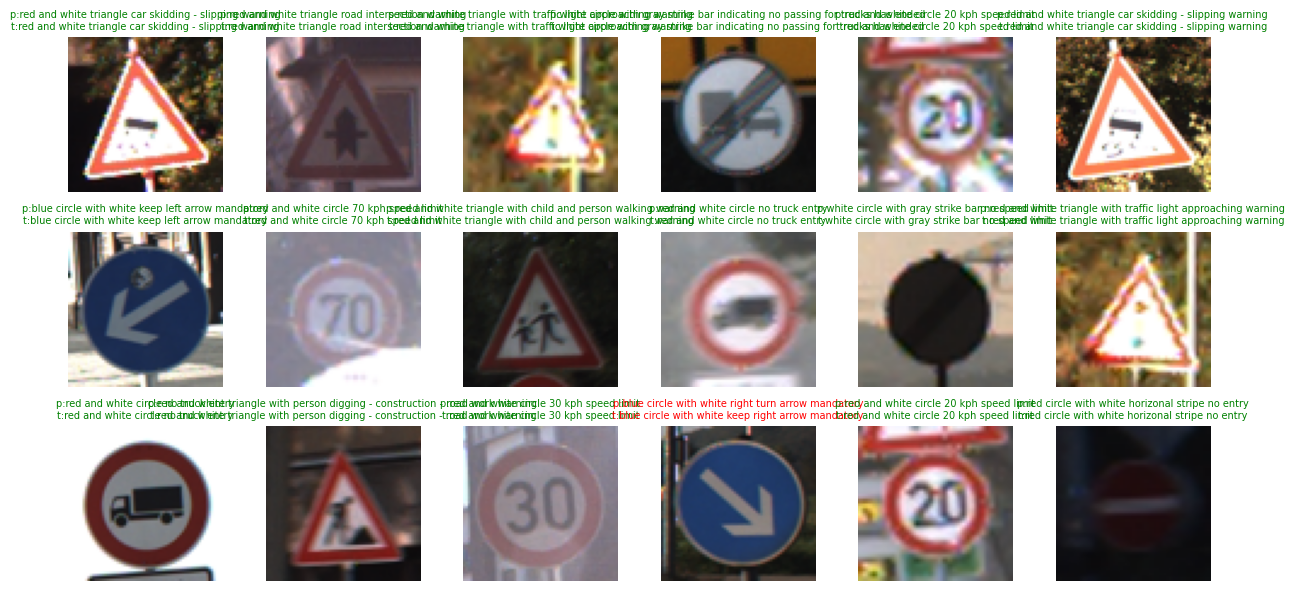

In [6]:
idx_all=np.arange(len(imgs))
from sklearn.model_selection import train_test_split as tts
_, idx_te = tts(idx_all, test_size=0.3, random_state=42, stratify=y)
show=idx_te[:18]
fig,ax=plt.subplots(3,6,figsize=(12,6))
for a,i in zip(ax.ravel(), show):
    a.imshow(imgs[i]); a.axis('off'); pr=clf.predict(X[i:i+1])[0]
    a.set_title('p:%s\nt:%s'%(pr,y[i]), color='green' if pr==y[i] else 'red', fontsize=7)
plt.tight_layout(); plt.show()

### Findings
Frozen ResNet18 features + logistic regression classify the 43 sign types with high accuracy (see the printed number). Residual confusions are between visually similar signs (speed-limit numbers, the various triangular warning signs). No CNN fine-tuning needed.